<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT2004i1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running QFT2004i1 (λ, k0) scan...
λ = 0.000, k0 = 0.000 | C_final = 1.0000, width_final = 0.8522, peak_final = 0.9958
λ = 0.000, k0 = 0.250 | C_final = 1.0000, width_final = 0.8154, peak_final = 0.9950
λ = 0.000, k0 = 0.500 | C_final = 1.0000, width_final = 0.7178, peak_final = 0.9926
λ = 0.000, k0 = 0.750 | C_final = 0.9999, width_final = 0.6097, peak_final = 0.9883
λ = 0.000, k0 = 1.000 | C_final = 0.9998, width_final = 0.5807, peak_final = 0.9813
λ = 0.000, k0 = 1.250 | C_final = 0.9996, width_final = 0.6574, peak_final = 0.9711
λ = 0.000, k0 = 1.500 | C_final = 0.9992, width_final = 0.7599, peak_final = 0.9567
λ = 0.000, k0 = 1.750 | C_final = 0.9985, width_final = 0.8329, peak_final = 0.9371
λ = 0.000, k0 = 2.000 | C_final = 0.9972, width_final = 0.8732, peak_final = 0.9116
λ = 0.000, k0 = 2.250 | C_final = 0.9953, width_final = 0.8945, peak_final = 0.8791
λ = 0.000, k0 = 2.500 | C_final = 0.9923, width_final = 0.9080, peak_final = 0.8394
λ = 0.000, k0 = 2.750 | C_final = 0.9878, 

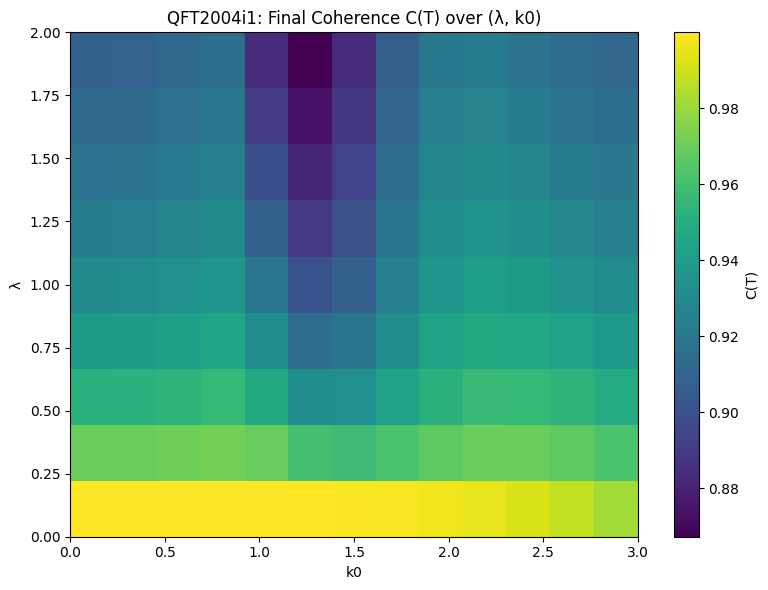

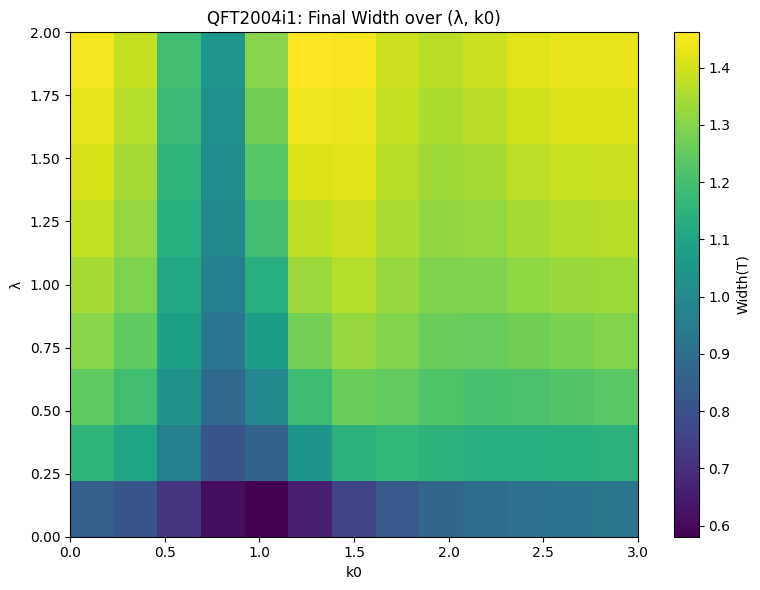

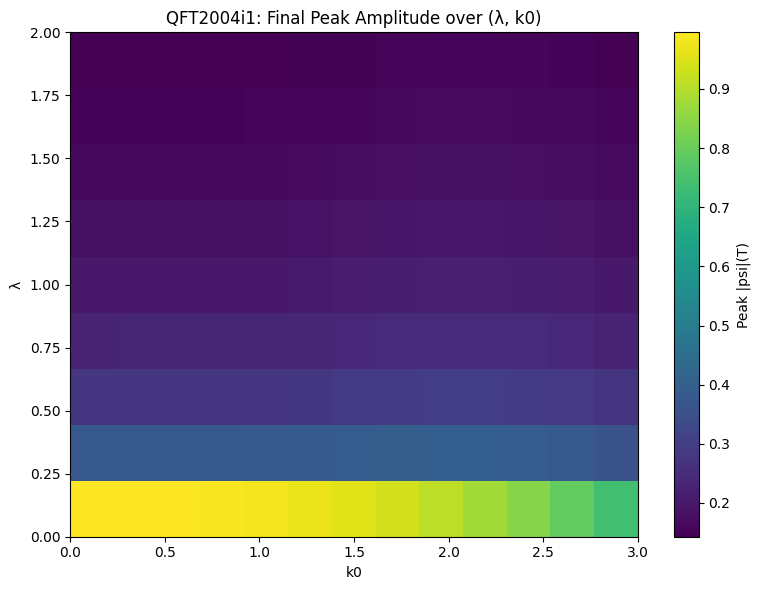


QFT2004i1 summary (extremes):
  C_min = 0.8672, C_max = 1.0000
  width_min = 0.5807, width_max = 1.4619
  peak_min = 0.1428, peak_max = 0.9958


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2004i1 — 2D Shape-Memory Map in (λ, k0)
# ============================================================

# --- Lattice parameters ---
N = 512
L = 50.0
dx = L / N
x = np.linspace(-L/2, L/2, N, endpoint=False)

# --- Time parameters ---
dt = 0.002
steps = 6000
t_final = steps * dt

# --- Physical parameters (fixed except λ, k0) ---
m = 1.0
A = 1.0
sigma = 1.2

# --- Precompute FFT wave numbers ---
k = 2*np.pi * np.fft.fftfreq(N, d=dx)

# --- Helper functions ---
def compute_width(field):
    norm = np.sum(field**2)
    mean = np.sum(x * field**2) / norm
    var = np.sum((x - mean)**2 * field**2) / norm
    return np.sqrt(var)

def compute_coherence(field, ref):
    num = np.abs(np.sum(field * ref))
    den = np.sqrt(np.sum(field**2) * np.sum(ref**2))
    return num / den

def evolve_and_measure(lam, k0, steps=steps, dt=dt):
    """
    For given (λ, k0):
      - build psi0(x; k0)
      - evolve under λ
      - return final coherence with psi0, width, peak amplitude
    """
    psi0 = A * np.exp(-(x**2)/(2*sigma**2)) * np.cos(k0 * x)
    psi = psi0.copy()

    for step in range(steps):
        # Nonlinear step
        psi_nl = psi - dt * lam * psi**3

        # Linear step via FFT
        psi_k = np.fft.fft(psi_nl)
        psi_k *= np.exp(-0.5j * (k**2 / m) * dt)
        psi = np.real(np.fft.ifft(psi_k))

    C_final = compute_coherence(psi, psi0)
    width_final = compute_width(psi)
    peak_final = np.max(np.abs(psi))
    return C_final, width_final, peak_final

# ============================================================
# Parameter grids
# ============================================================

lambda_values = np.linspace(0.0, 2.0, 9)      # 0.0 ... 2.0
k0_values     = np.linspace(0.0, 3.0, 13)     # 0.0 ... 3.0

n_lam = len(lambda_values)
n_k0  = len(k0_values)

C_map     = np.zeros((n_lam, n_k0))
width_map = np.zeros((n_lam, n_k0))
peak_map  = np.zeros((n_lam, n_k0))

print("Running QFT2004i1 (λ, k0) scan...")
for i, lam in enumerate(lambda_values):
    for j, k0 in enumerate(k0_values):
        C_final, w_final, p_final = evolve_and_measure(lam, k0)
        C_map[i, j]     = C_final
        width_map[i, j] = w_final
        peak_map[i, j]  = p_final
        print(f"λ = {lam:.3f}, k0 = {k0:.3f} | C_final = {C_final:.4f}, width_final = {w_final:.4f}, peak_final = {p_final:.4f}")

# ============================================================
# Plotting: heatmaps over (λ, k0)
# ============================================================

Lambda, K0 = np.meshgrid(k0_values, lambda_values)  # note: x=k0, y=λ for plotting

def plot_heatmap(data, title, cbar_label):
    plt.figure(figsize=(8,6))
    im = plt.imshow(
        data,
        origin='lower',
        aspect='auto',
        extent=[k0_values[0], k0_values[-1], lambda_values[0], lambda_values[-1]]
    )
    plt.colorbar(im, label=cbar_label)
    plt.xlabel("k0")
    plt.ylabel("λ")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_heatmap(C_map,     "QFT2004i1: Final Coherence C(T) over (λ, k0)", "C(T)")
plot_heatmap(width_map, "QFT2004i1: Final Width over (λ, k0)",          "Width(T)")
plot_heatmap(peak_map,  "QFT2004i1: Final Peak Amplitude over (λ, k0)", "Peak |psi|(T)")

# ============================================================
# Brief printed summary (extremes)
# ============================================================
print("\nQFT2004i1 summary (extremes):")
print(f"  C_min = {C_map.min():.4f}, C_max = {C_map.max():.4f}")
print(f"  width_min = {width_map.min():.4f}, width_max = {width_map.max():.4f}")
print(f"  peak_min = {peak_map.min():.4f}, peak_max = {peak_map.max():.4f}")


Running QFT2004i2 (λ, m) scan...
λ = 0.000, m = 0.500 | C_final = 0.9911, width_final = 0.8121, peak_final = 0.8612
λ = 0.000, m = 0.650 | C_final = 0.9963, width_final = 0.7858, peak_final = 0.9082
λ = 0.000, m = 0.800 | C_final = 0.9982, width_final = 0.7711, peak_final = 0.9355
λ = 0.000, m = 0.950 | C_final = 0.9991, width_final = 0.7621, peak_final = 0.9525
λ = 0.000, m = 1.100 | C_final = 0.9995, width_final = 0.7563, peak_final = 0.9636
λ = 0.000, m = 1.250 | C_final = 0.9997, width_final = 0.7523, peak_final = 0.9714
λ = 0.000, m = 1.400 | C_final = 0.9998, width_final = 0.7494, peak_final = 0.9769
λ = 0.000, m = 1.550 | C_final = 0.9999, width_final = 0.7473, peak_final = 0.9810
λ = 0.000, m = 1.700 | C_final = 0.9999, width_final = 0.7457, peak_final = 0.9841
λ = 0.000, m = 1.850 | C_final = 0.9999, width_final = 0.7445, peak_final = 0.9865
λ = 0.000, m = 2.000 | C_final = 0.9999, width_final = 0.7435, peak_final = 0.9884
λ = 0.250, m = 0.500 | C_final = 0.9566, width_final =

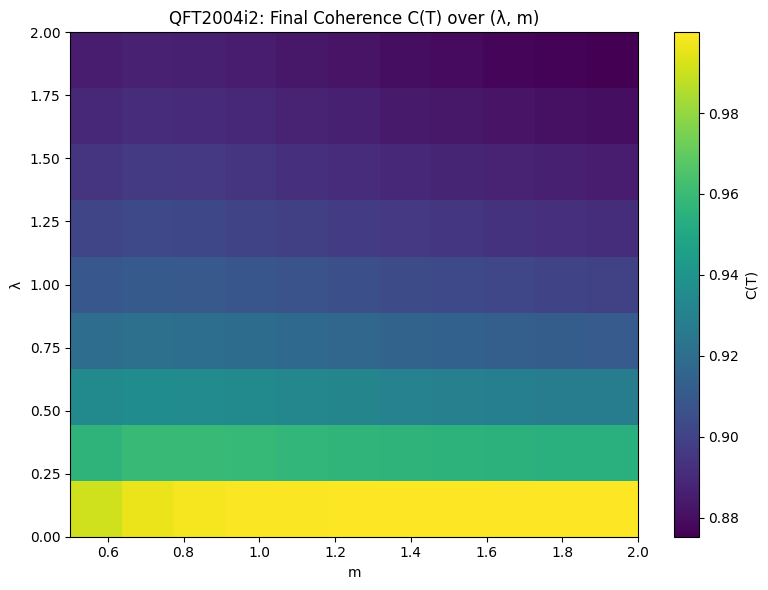

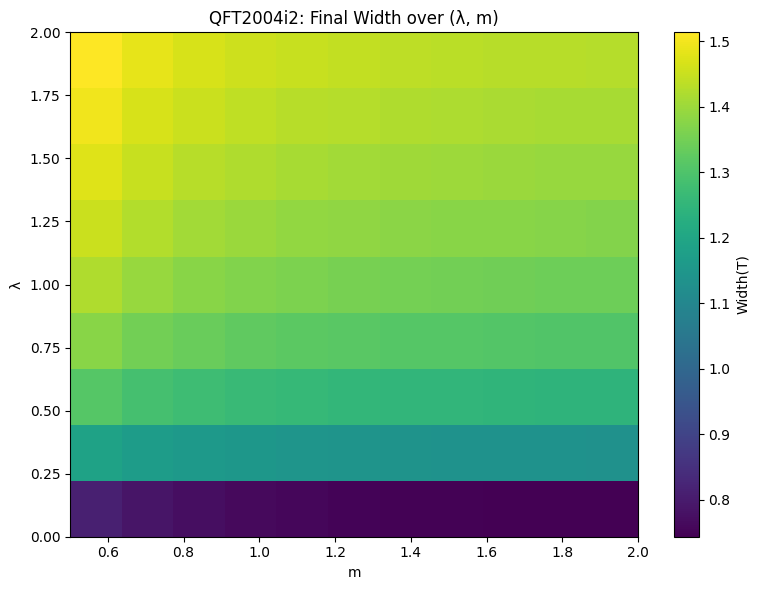

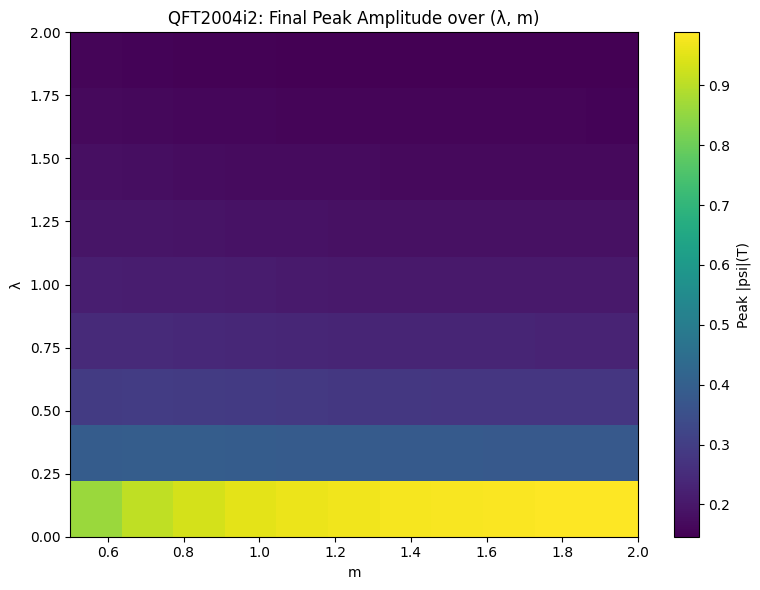


QFT2004i2 summary (extremes):
  C_min = 0.8753, C_max = 0.9999
  width_min = 0.7435, width_max = 1.5136
  peak_min = 0.1462, peak_max = 0.9884


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2004i2 — 2D Shape-Memory Map in (λ, m)
# ============================================================

# --- Lattice parameters ---
N = 512
L = 50.0
dx = L / N
x = np.linspace(-L/2, L/2, N, endpoint=False)

# --- Time parameters ---
dt = 0.002
steps = 6000
t_final = steps * dt

# --- Physical parameters (fixed except λ, m) ---
A = 1.0
sigma = 1.2
k0 = 1.5

# --- Precompute FFT wave numbers (k) ---
k = 2*np.pi * np.fft.fftfreq(N, d=dx)

# --- Initial packet (fixed across scan) ---
psi0 = A * np.exp(-(x**2)/(2*sigma**2)) * np.cos(k0 * x)

# --- Helper functions ---
def compute_width(field):
    norm = np.sum(field**2)
    mean = np.sum(x * field**2) / norm
    var = np.sum((x - mean)**2 * field**2) / norm
    return np.sqrt(var)

def compute_coherence(field, ref):
    num = np.abs(np.sum(field * ref))
    den = np.sqrt(np.sum(field**2) * np.sum(ref**2))
    return num / den

def evolve_and_measure(lam, m, steps=steps, dt=dt):
    """
    For given (λ, m):
      - evolve psi starting from fixed psi0
      - return final coherence with psi0, width, peak amplitude
    """
    psi = psi0.copy()
    for step in range(steps):
        # Nonlinear step
        psi_nl = psi - dt * lam * psi**3

        # Linear step via FFT (m-dependent dispersion)
        psi_k = np.fft.fft(psi_nl)
        psi_k *= np.exp(-0.5j * (k**2 / m) * dt)
        psi = np.real(np.fft.ifft(psi_k))

    C_final = compute_coherence(psi, psi0)
    width_final = compute_width(psi)
    peak_final = np.max(np.abs(psi))
    return C_final, width_final, peak_final

# ============================================================
# Parameter grids
# ============================================================

lambda_values = np.linspace(0.0, 2.0, 9)   # 0.0 ... 2.0
m_values      = np.linspace(0.5, 2.0, 11)  # 0.5 ... 2.0

n_lam = len(lambda_values)
n_m   = len(m_values)

C_map     = np.zeros((n_lam, n_m))
width_map = np.zeros((n_lam, n_m))
peak_map  = np.zeros((n_lam, n_m))

print("Running QFT2004i2 (λ, m) scan...")
for i, lam in enumerate(lambda_values):
    for j, m_val in enumerate(m_values):
        C_final, w_final, p_final = evolve_and_measure(lam, m_val)
        C_map[i, j]     = C_final
        width_map[i, j] = w_final
        peak_map[i, j]  = p_final
        print(f"λ = {lam:.3f}, m = {m_val:.3f} | C_final = {C_final:.4f}, width_final = {w_final:.4f}, peak_final = {p_final:.4f}")

# ============================================================
# Plotting: heatmaps over (λ, m)
# ============================================================

def plot_heatmap(data, title, cbar_label):
    plt.figure(figsize=(8,6))
    im = plt.imshow(
        data,
        origin='lower',
        aspect='auto',
        extent=[m_values[0], m_values[-1], lambda_values[0], lambda_values[-1]]
    )
    plt.colorbar(im, label=cbar_label)
    plt.xlabel("m")
    plt.ylabel("λ")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_heatmap(C_map,     "QFT2004i2: Final Coherence C(T) over (λ, m)", "C(T)")
plot_heatmap(width_map, "QFT2004i2: Final Width over (λ, m)",          "Width(T)")
plot_heatmap(peak_map,  "QFT2004i2: Final Peak Amplitude over (λ, m)", "Peak |psi|(T)")

# ============================================================
# Brief printed summary (extremes)
# ============================================================
print("\nQFT2004i2 summary (extremes):")
print(f"  C_min = {C_map.min():.4f}, C_max = {C_map.max():.4f}")
print(f"  width_min = {width_map.min():.4f}, width_max = {width_map.max():.4f}")
print(f"  peak_min = {peak_map.min():.4f}, peak_max = {peak_map.max():.4f}")
